**выполнил: Тихомиров Максим**

# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle.

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, make_scorer
import importlib

import drive.MyDrive.Colab_Notebooks.hw2code
importlib.reload(drive.MyDrive.Colab_Notebooks.hw2code)
from drive.MyDrive.Colab_Notebooks.hw2code import DecisionTree
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [104]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [105]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

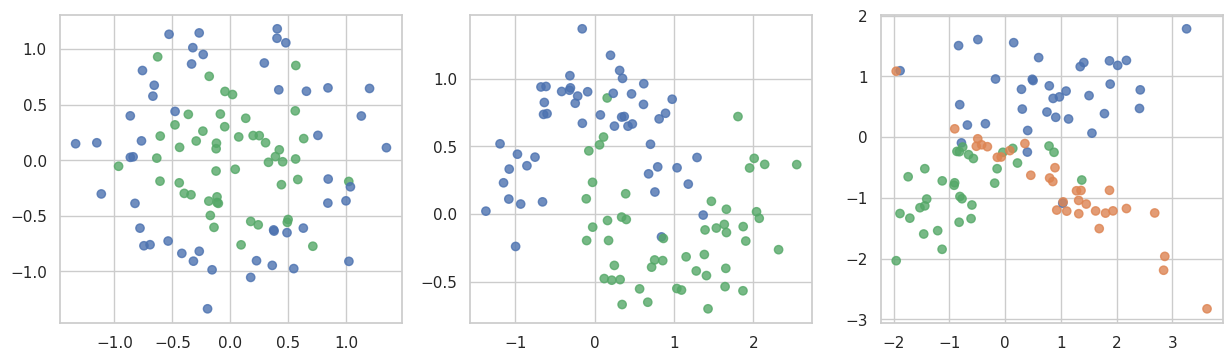

In [106]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [107]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

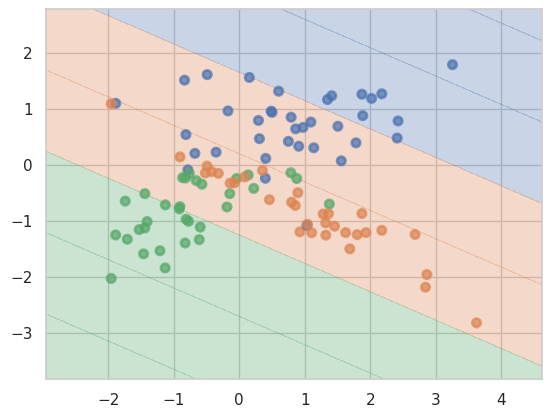

In [108]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

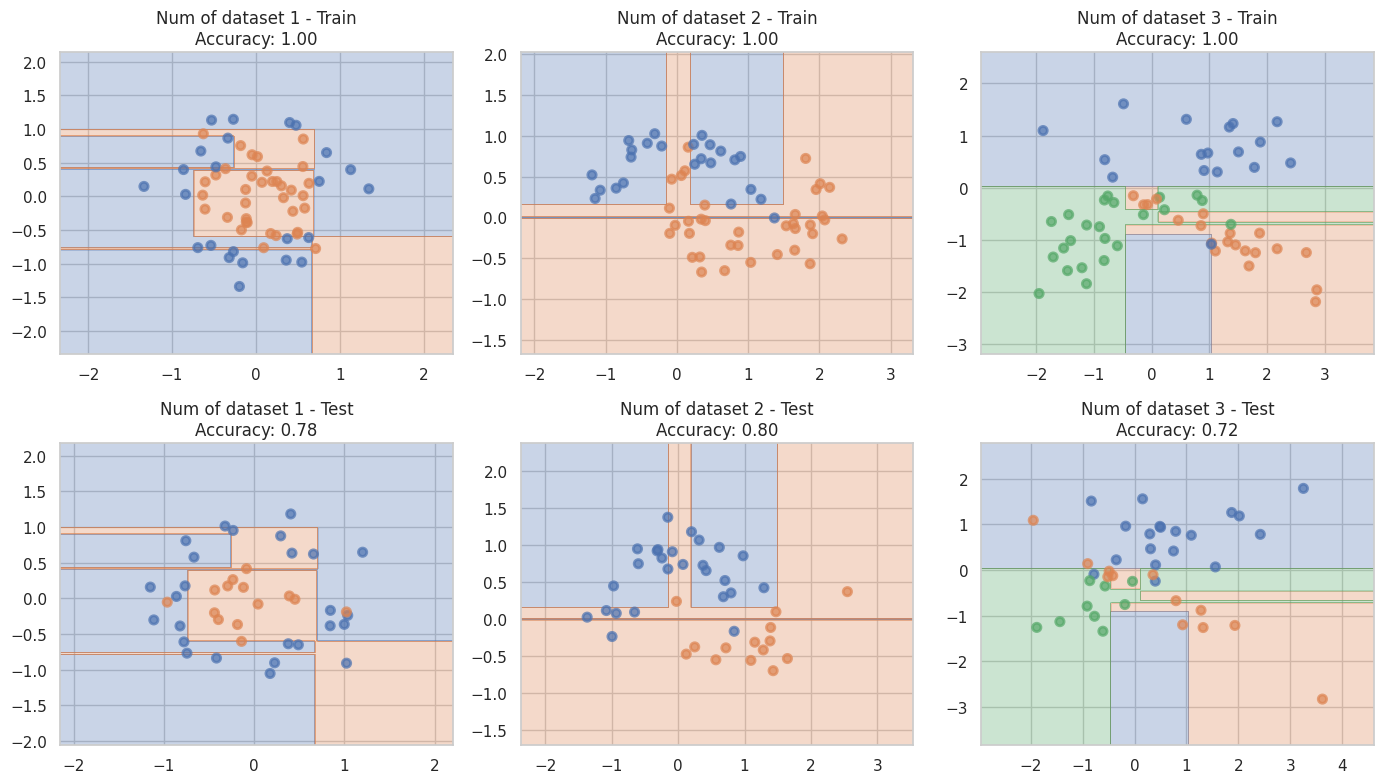

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

for i, (x, y) in enumerate(datasets):
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

  tree = DecisionTreeClassifier(random_state=42)
  tree.fit(x_train, y_train)

  train = accuracy_score(y_train, tree.predict(x_train))
  test = accuracy_score(y_test, tree.predict(x_test))

  plt.sca(axes[0, i])
  plot_surface(tree, x_train, y_train)
  plt.title(f"Num of dataset {i + 1} - Train\nAccuracy: {train:.2f}")

  plt.sca(axes[1, i])
  plot_surface(tree, x_test, y_test)
  plt.title(f"Num of dataset {i + 1} - Test\nAccuracy: {test:.2f}")

plt.tight_layout()
plt.show()



__Ответ:__ Деревья сильно переобучились

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

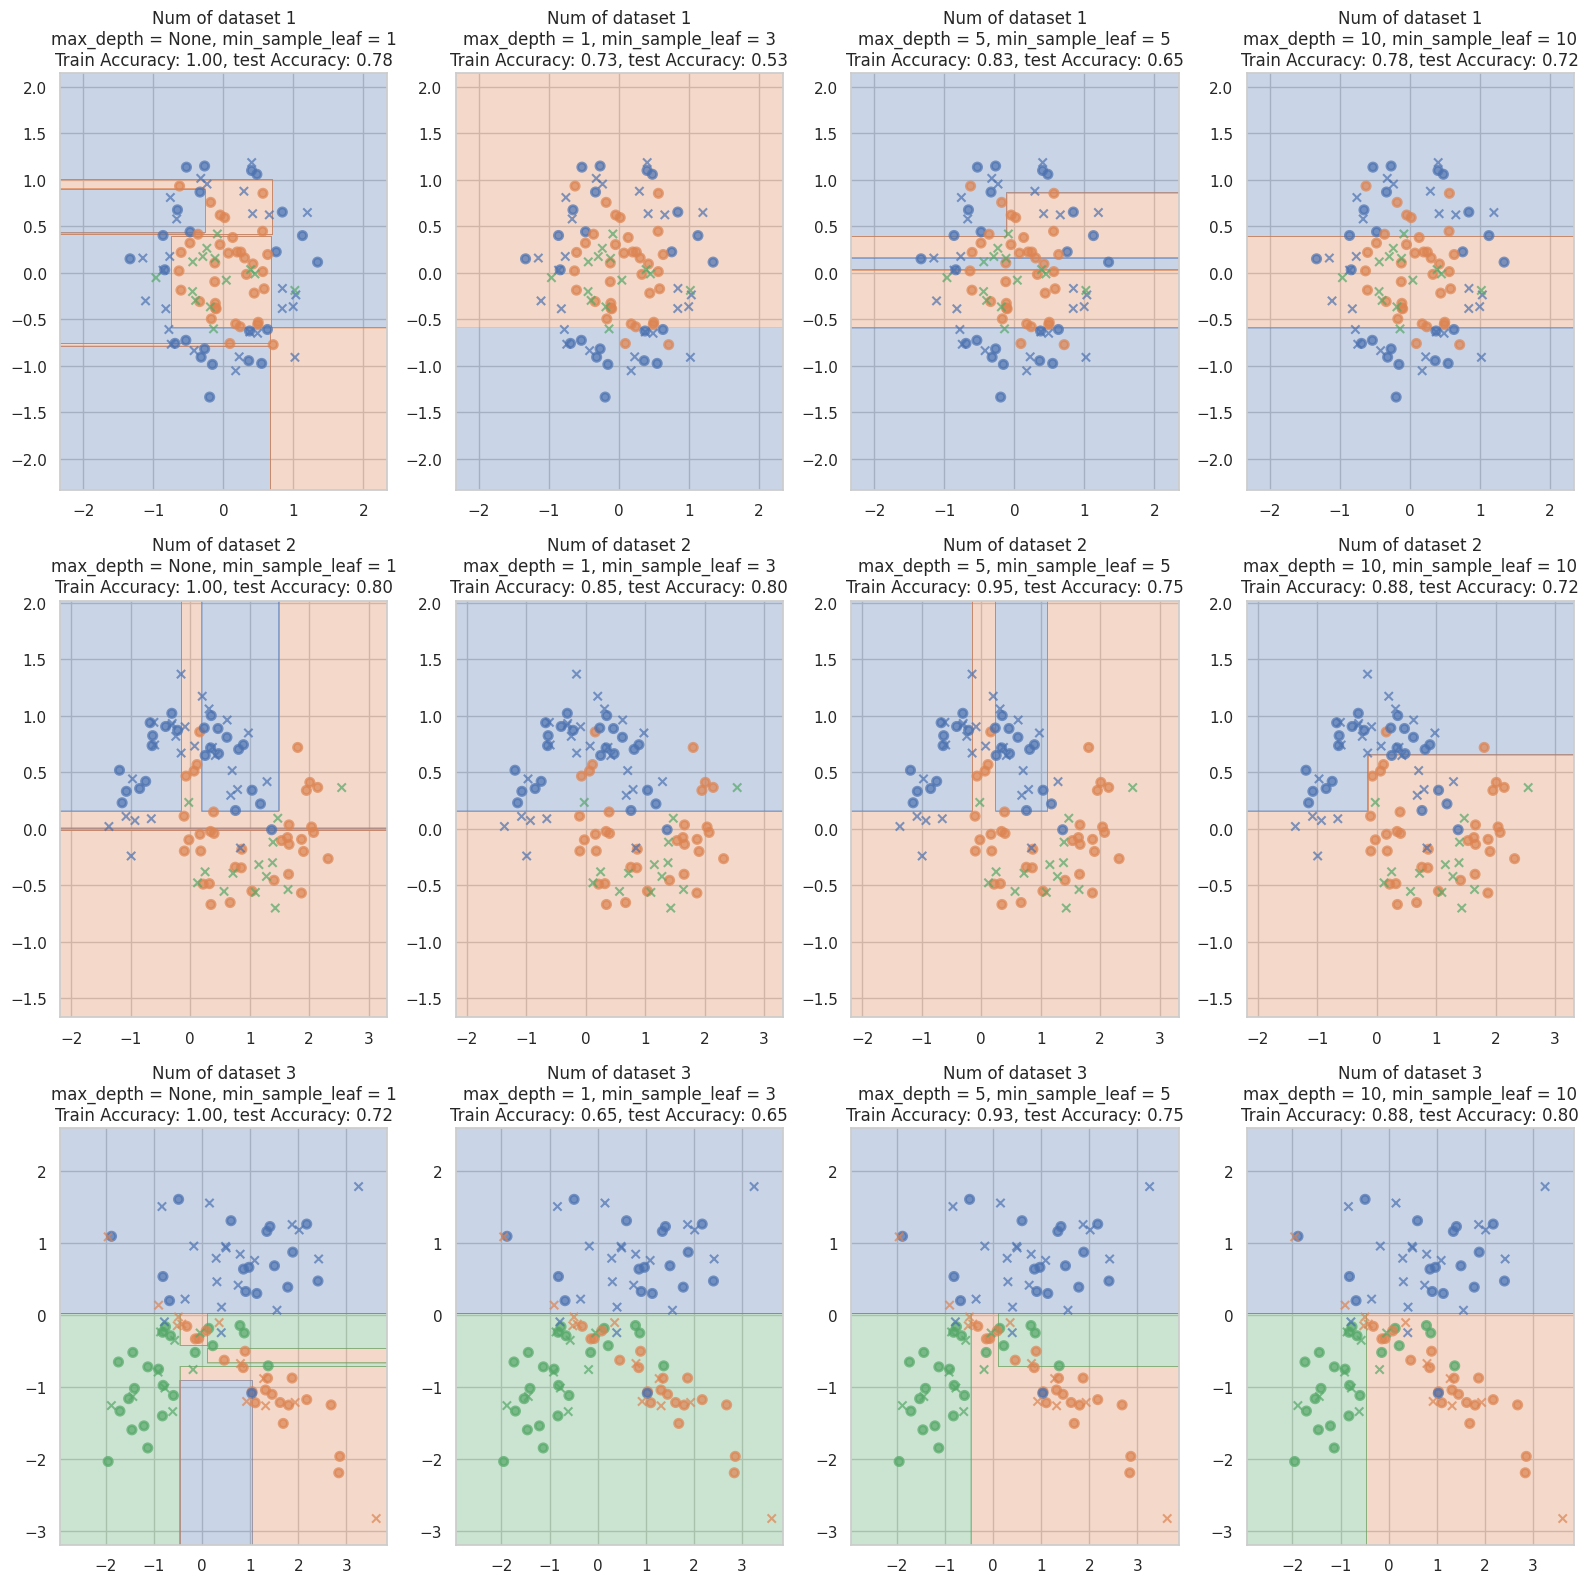

In [112]:
max_depth_exmpl = [None, 1, 5, 10]
min_samples_leaves = [1, 3, 5, 10]

fig, axes = plt.subplots(len(datasets), len(max_depth_exmpl), figsize=(16, 16))

for data_ind, (x, y) in enumerate(datasets):
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)


  for ind, _max_depth in enumerate(max_depth_exmpl):
    tree = DecisionTreeClassifier(
        max_depth=_max_depth,
        min_samples_leaf=min_samples_leaves[ind],
        random_state=42
    )
    tree.fit(x_train, y_train)
    train = accuracy_score(y_train, tree.predict(x_train))
    test = accuracy_score(y_test, tree.predict(x_test))

    plt.sca(axes[data_ind, ind])
    plot_surface(tree, x_train, y_train)


    plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y_test], marker = 'x')
    plt.title(f"Num of dataset {data_ind + 1}\nmax_depth = {_max_depth}, min_sample_leaf = {min_samples_leaves[ind]}\nTrain Accuracy: {train:.2f}, test Accuracy: {test:.2f}")

plt.tight_layout()
plt.show()


__Ответ:__

Без ограничений регуляризации деревья строят чрезмерно сложные разделяющие поверхности, которые учитывают даже шумовые выбросы и мелкие особенности обучающей выборки. При добавлении ограничивающих параметров (максимальная глубина, минимальное число образцов для разбиения и в листе) поверхность становится более сглаженной и менее "зубчатой".

Результаты регуляризации по датасетам:

* Для первых двух наборов данных обобщающая способность улучшилась. Это указывает на то, что данные имеют относительно простую структуру, и регуляризация помогает подавить переобучение на шуме.

* Для последнего набора данных качество снизилось. Это объясняется тем, что данный датасет содержит более сложные внутренние зависимости. Слишком строгая регуляризация приводит к недообучению — дерево становится слишком простым и не может уловить важные закономерности в данных.


# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

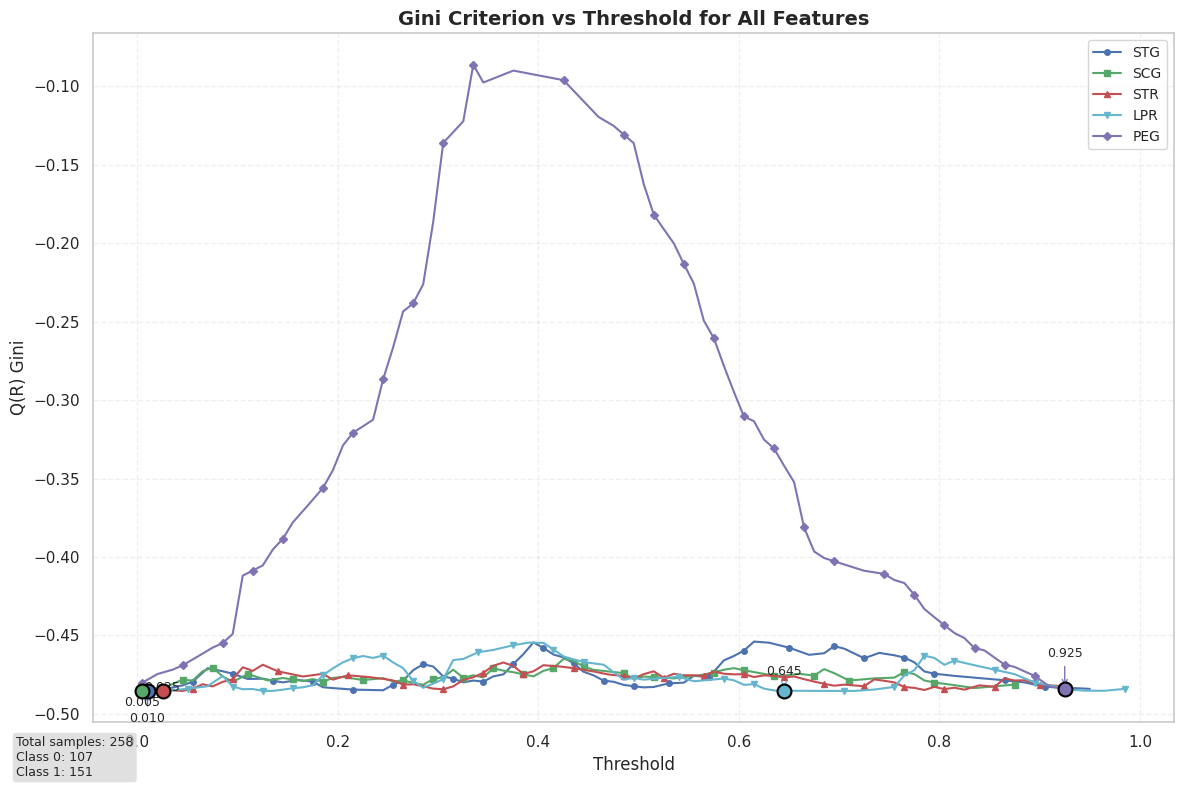

Лучшие пороги для каждого признака:
Feature    Best Threshold  Best Gini       Num Thresholds 
STG        0.0100          -0.4853         74             
SCG        0.0050          -0.4853         70             
STR        0.0250          -0.4854         82             
LPR        0.6450          -0.4855         79             
PEG        0.9250          -0.4841         78             


In [113]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/dataset/students.csv")
feature_names = ["STG", "SCG", "STR", "LPR", "PEG"]
X = df[feature_names].values.astype(float)
y = df["UNS"].values.astype(int)

plt.figure(figsize=(12, 8))

colors = ['b', 'g', 'r', 'c', 'm']
markers = ['o', 's', '^', 'v', 'D']

for idx, feature in enumerate(feature_names):
    thresholds, ginis, threshold_best, gini_best = find_best_split(X[:, idx], y)

    if len(thresholds) > 0:
        plt.plot(thresholds, ginis,
                color=colors[idx % len(colors)],
                marker=markers[idx % len(markers)],
                markersize=4,
                markevery=len(thresholds)//20 if len(thresholds) > 20 else 1,
                linewidth=1.5,
                label=f'{feature}')

        if threshold_best is not None:
            plt.scatter(threshold_best, gini_best,
                       color=colors[idx % len(colors)],
                       s=100, zorder=5,
                       edgecolors='black', linewidth=1.5)
            plt.annotate(f'{threshold_best:.3f}',
                        xy=(threshold_best, gini_best),
                        xytext=(threshold_best, gini_best + 0.01 * (idx - 2)),
                        ha='center', fontsize=9,
                        arrowprops=dict(arrowstyle='->', lw=1, color=colors[idx % len(colors)]))

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Q(R) Gini', fontsize=12)
plt.title('Gini Criterion vs Threshold for All Features', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.figtext(0.02, 0.02, f'Total samples: {len(y)}\nClass 0: {np.sum(y==0)}\nClass 1: {np.sum(y==1)}',
           fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

plt.show()

print("Лучшие пороги для каждого признака:")
print(f"{'Feature':<10} {'Best Threshold':<15} {'Best Gini':<15} {'Num Thresholds':<15}")

for idx, feature in enumerate(feature_names):
    thresholds, ginis, threshold_best, gini_best = find_best_split(X[:, idx], y)
    if threshold_best is not None:
        print(f"{feature:<10} {threshold_best:<15.4f} {gini_best:<15.4f} {len(thresholds):<15}")
    else:
        print(f"{feature:<10} {'N/A':<15} {'N/A':<15} {len(thresholds):<15}")



In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** По признаку PEG надо производить деление выборки на 2 поддерева, так как его кривая имеет наибольшее значение критерия Джини, а остальные признаки дают почти плоские значения Q. У признаков, по которым деление почти невозможно кривая почти плоская, сильно ниже нуля

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [114]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/dataset/agaricus-lepiota.data", header=None, sep=",")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [115]:
y = df.iloc[:, 0].copy()
X = df.iloc[:, 1:].copy()
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y.values)
X_enc = X.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_enc.values.astype(int),
    y_enc.astype(int),
    test_size=0.2,
    random_state=42,
)
feature_types = ["categorical"] * X_tr.shape[1]

tree = DecisionTree(feature_types=feature_types)
tree.fit(X_tr, y_tr)
pred = tree.predict(X_te)

acc = accuracy_score(y_te, pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 1.0000


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

In [116]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/dataset/tic-tac-toe-endgame.csv")
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


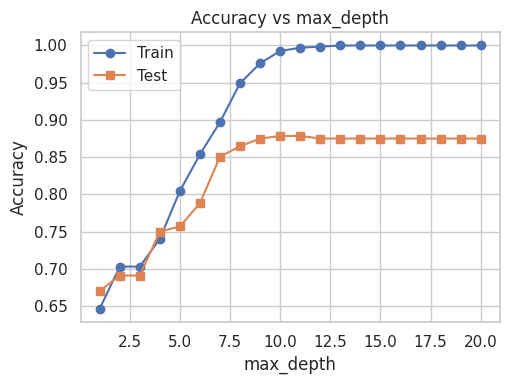

In [117]:
X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y.values)
X_enc = X.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_enc.values.astype(int), y_enc.astype(int), test_size=0.3, random_state=42
)
feature_types = ["categorical"] * X_tr.shape[1]
train_acc, test_acc = [], []
depths= range(1,21)
for d in depths:
    tree = DecisionTree(feature_types=feature_types, max_depth=d)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(depths, train_acc, label='Train', marker='o')
plt.plot(depths, test_acc, label='Test', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs max_depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

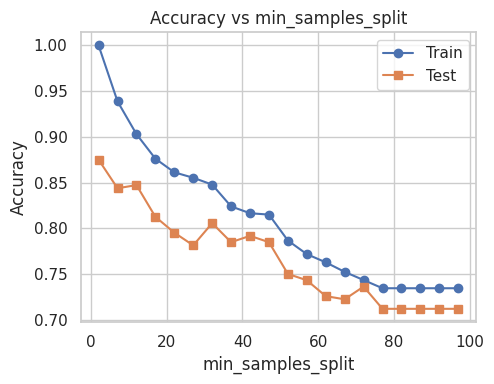

In [118]:
splits = range(2, 101, 5)
train_acc, test_acc = [], []

for s in splits:
    tree = DecisionTree(feature_types=feature_types, min_samples_split=s)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 2)
plt.plot(splits, train_acc, label='Train', marker='o')
plt.plot(splits, test_acc, label='Test', marker='s')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_split')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

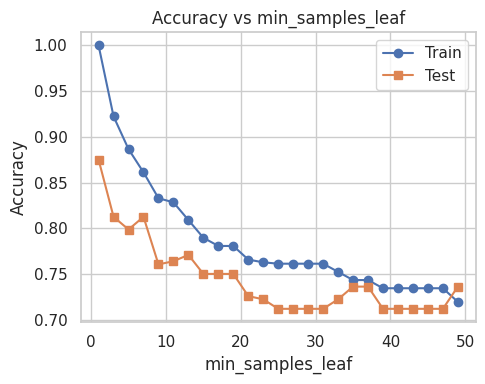

In [119]:
leafs = range(1, 51, 2)
train_acc, test_acc = [], []

for l in leafs:
    tree = DecisionTree(feature_types=feature_types, min_samples_leaf=l)
    tree.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, tree.predict(X_te)))

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 3)
plt.plot(leafs, train_acc, label='Train', marker='o')
plt.plot(leafs, test_acc, label='Test', marker='s')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_leaf')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [120]:
df_mush = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/dataset/agaricus-lepiota.data", header=None, sep=",")
y_mush = LabelEncoder().fit_transform(df_mush.iloc[:, 0].values)
X_mush = df_mush.iloc[:, 1:].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_mush = X_mush.values.astype(int)


df_ttt = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/dataset/tic-tac-toe-endgame.csv")
y_ttt = LabelEncoder().fit_transform(df_ttt.iloc[:, -1].values)
X_ttt = df_ttt.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_ttt = X_ttt.values.astype(int)

df_cars = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data",
                      header=None)
y_cars_raw = df_cars.iloc[:, -1].values
y_cars = np.array([0 if y in ['unacc', 'acc'] else 1 for y in y_cars_raw])
X_cars = df_cars.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_cars = X_cars.values.astype(int)

df_nurs = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data",
                      header=None)

y_nurs_raw = df_nurs.iloc[:, -1].values
y_nurs = np.array([0 if y in ['not_recom', 'recommend'] else 1 for y in y_nurs_raw])
X_nurs = df_nurs.iloc[:, :-1].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
X_nurs = X_nurs.values.astype(int)

datasets_dict = {
    'mushrooms': (X_mush, y_mush),
    'tic-tac-toe': (X_ttt, y_ttt),
    'cars': (X_cars, y_cars),
    'nursery': (X_nurs, y_nurs)
}

scorer = make_scorer(accuracy_score)
results = {}

for name, (X, y) in datasets_dict.items():

    n_features = X.shape[1]

    tree_real = DecisionTree(feature_types=['real'] * n_features)
    scores_real = cross_val_score(tree_real, X, y, cv=10, scoring=scorer)

    tree_cat = DecisionTree(feature_types=['categorical'] * n_features)
    scores_cat = cross_val_score(tree_cat, X, y, cv=10, scoring=scorer)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X)
    tree_ohe = DecisionTree(feature_types=['real'] * X_ohe.shape[1])
    scores_ohe = cross_val_score(tree_ohe, X_ohe, y, cv=10, scoring=scorer)

    clf_sklearn = DecisionTreeClassifier(random_state=42)
    scores_sklearn = cross_val_score(clf_sklearn, X, y, cv=10, scoring=scorer)

    results[name] = {
        'DT (real)': scores_real.mean(),
        'DT (categorical)': scores_cat.mean(),
        'DT (real + OHE)': scores_ohe.mean(),
        'sklearn DT': scores_sklearn.mean()
    }

results_df = pd.DataFrame(results).T
print("\n=== Results ===")
print(results_df)


=== Results ===
             DT (real)  DT (categorical)  DT (real + OHE)  sklearn DT
mushrooms     1.000000          1.000000         0.999631    0.960384
tic-tac-toe   0.279046          0.531985         0.544616    0.771678
cars          0.954241          0.881940         0.919495    0.942707
nursery       0.999691          0.999846         0.999537    0.999691


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

__Ответ__:

mushrooms: Оба подхода (DT real и DT categorical) достигли идеальной точности (1.000), что свидетельствует о высокой предсказуемости данных. При этом обработка признаков как категориальных наиболее адекватна природе данных, так как признаки описывают качественные характеристики грибов, не имеющие естественного порядка. Результат sklearn несколько ниже, возможно, из-за различий в стратегиях регуляризации или выбора порогов.

tic-tac-toe: Здесь sklearn DT значительно превосходит все остальные подходы (0.772 против 0.280–0.545). Столь низкие результаты реализации объясняются тем, что в игре важны не значения отдельных клеток, а их совместные конфигурации. Алгоритм, основанный на жадном выборе разбиений по отдельным признакам, не может эффективно выявлять такие сложные взаимодействия, тогда как sklearn использует более совершенные эвристики и оптимизации.

cars: Лучший результат показал подход с вещественными признаками (DT real, 0.954), хотя категориальный подход (DT categorical, 0.882) оказался существенно хуже. Категориальное кодирование, игнорирующее этот порядок, теряет часть информации. One-Hot Encoding (DT real + OHE) дал промежуточный результат (0.919), вероятно, из-за увеличения размерности.

nursery: Все методы показали почти идеальную точность (~0.999), что указывает на простоту данных и явную зависимость целевой переменной от признаков независимо от способа их кодирования.

Влияние случайности:

Результаты содержат компоненту случайности, которая проявляется в:

* Разбиении на фолды при кросс-валидации — разные разбиения могут
давать отличающиеся оценки.

* Порядке просмотра признаков — если несколько признаков имеют одинаковое значение критерия Джини, выбор конкретного признака может быть недетерминированным.

Для того чтобы, улучшить устойчивость и качество алгоритмов можно фиксировать random_state при разбиении данных для воспроизводимости.



Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [121]:
print("✓deadinside✓emo✓drain✓epileptic✓paranoid✓toxic✓bipolar✓depressed✓tilted✓antisocial✓sad✓broken✓aggressive✓psycho✓apathetic✓broken-hearted✓")

✓deadinside✓emo✓drain✓epileptic✓paranoid✓toxic✓bipolar✓depressed✓tilted✓antisocial✓sad✓broken✓aggressive✓psycho✓apathetic✓broken-hearted✓
